# HKT Single-Country Production: Larger Bubble Share Calibration

This notebook starts from `11_single_country_production_hkt_increasing_q.ipynb` and keeps its recalibrated production-side parameters (`lambda_u = 1.5`, `xi_u = 2.0`) while changing only the requested bubble-share parameters:

- `pi = 0.80`
- `lambda_b = xi_b = 0.50`
- `gamma = 0.25`

The cells below compute the all-`u` path, the rational fundamental value and bubble path, and plots of the endogenous all-`u` variables.

In [1]:
using Pkg

function find_project_dir(start_dir=pwd())
    dir = start_dir
    while true
        isfile(joinpath(dir, "Project.toml")) && return dir
        parent = dirname(dir)
        parent == dir && return start_dir
        dir = parent
    end
end

const PROJECT_DIR = find_project_dir()
Pkg.activate(PROJECT_DIR)

include(joinpath(PROJECT_DIR, "Single_country_production", "SingleCountryProductionOLG.jl"))

using Plots, LaTeXStrings, Printf
using Plots.PlotMeasures

gr()

const OUTDIR = joinpath(PROJECT_DIR, "outputs_hkt_single_country_larger_bubble_share")
isdir(OUTDIR) || mkpath(OUTDIR)

default(size=(860, 540), framestyle=:box, grid=:y, legend=:best,
        fontfamily="Computer Modern", linewidth=2,
        titlefontsize=11, guidefontsize=10, tickfontsize=9, legendfontsize=8,
        left_margin=8mm, right_margin=6mm, top_margin=7mm, bottom_margin=8mm)

p = HKTParams(T=100, λu=1.5, ξu=2.0, λb=0.5, ξb=0.5, γ=0.25)
pi_persist = 0.80

println("HKT single-country production: larger bubble-share calibration")
println("-"^78)
@printf("%-10s %-10s %-10s %-10s %-10s %-10s\n", "beta", "gamma", "alpha", "rho", "theta", "aH")
@printf("%-10.3f %-10.3f %-10.3f %-10.3f %-10.3f %-10.3f\n", p.β, p.γ, p.α, p.ρ, p.θ, p.aH)
println()
@printf("%-10s %-10s %-10s %-10s %-10s %-10s %-10s\n", "pi", "A_XH", "A_LL", "xi_u", "lambda_u", "xi_b", "lambda_b")
@printf("%-10.3f %-10.3f %-10.3f %-10.3f %-10.3f %-10.3f %-10.3f\n", pi_persist, p.A_XH, p.A_LL, p.ξu, p.λu, p.ξb, p.λb)
println()
println("Output directory: ", OUTDIR)

  Activating 

HKT single-country production: larger bubble-share calibration


project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


------------------------------------------------------------------------------
beta       gamma      alpha      rho        theta      aH        
0.500      0.250      0.500      2.000      0.500      0.200     

pi         A_XH       A_LL       xi_u       lambda_u   xi_b       lambda_b  
0.800      10.000     1.000      2.000      1.500      0.500      0.500     

Output directory: /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/outputs_hkt_single_country_larger_bubble_share


## Rational all-`u` bubble recursion

The helper below is the same recursion used in the source notebook: along the all-`u` branch, `q_t^u` is the HKT stock price, `V_t^u` is the rational fundamental value, and `B_t^u = q_t^u - V_t^u` is the rational bubble.

In [2]:
stock_price_from_block(block, n) = block.PD_pv * (block.D / n)
per_dividend_from_block(block, n) = block.D / n

function geom_ratio_tail(x::AbstractVector{<:Real}; k::Int=80)
    T = length(x)
    k = clamp(k, 5, T - 1)
    idx = collect((T-k+1):T)
    vals = Float64.(x[idx])
    vals = max.(vals, eps(Float64))
    xs = Float64.(idx)
    ys = log.(vals)
    xbar, ybar = sum(xs)/length(xs), sum(ys)/length(ys)
    slope = sum((xs .- xbar) .* (ys .- ybar)) / sum(abs2, xs .- xbar)
    r = exp(slope)
    tail = (0 < r < 1) ? vals[end] * r / (1 - r) : 0.0
    return (r=r, tail=tail)
end

function hkt_rational_bubble_path(p::HKTParams; pi_persist::Float64=0.80,
                                  T_ext::Int=600, tail_k::Int=80)
    @assert 0 < pi_persist < 1
    p_ext = HKTParams(β=p.β, γ=p.γ, α=p.α, ρ=p.ρ, θ=p.θ,
                      A_XH=p.A_XH, A_LL=p.A_LL,
                      ξu=p.ξu, λu=p.λu, ξb=p.ξb, λb=p.λb,
                      aH=p.aH, n0=p.n0, T=T_ext)

    n = Vector{Float64}(undef, T_ext + 1)
    n[1] = p_ext.n0
    q_u = zeros(T_ext + 1); d_u = zeros(T_ext + 1)
    q_b = zeros(T_ext + 1); d_b = zeros(T_ext + 1)
    phi_u = zeros(T_ext + 1); G_u = zeros(T_ext + 1)

    for i in 1:(T_ext + 1)
        u = hkt_block(p_ext, n[i], :u)
        b = hkt_block(p_ext, n[i], :b)
        q_u[i] = stock_price_from_block(u, n[i])
        d_u[i] = per_dividend_from_block(u, n[i])
        q_b[i] = stock_price_from_block(b, n[i])
        d_b[i] = per_dividend_from_block(b, n[i])
        phi_u[i], G_u[i] = u.φ, u.G
        i <= T_ext && (n[i + 1] = u.G * n[i])
    end

    factor = zeros(T_ext)
    for i in 1:T_ext
        den = pi_persist * (q_u[i + 1] + d_u[i + 1])^(1 - p_ext.γ) +
              (1 - pi_persist) * (q_b[i + 1] + d_b[i + 1])^(1 - p_ext.γ)
        m_u = q_u[i] * (q_u[i + 1] + d_u[i + 1])^(-p_ext.γ) / den
        factor[i] = pi_persist * m_u * q_u[i + 1] / q_u[i]
    end

    loss = -log.(clamp.(factor, eps(Float64), 1.0))
    tail = geom_ratio_tail(loss; k=tail_k)

    log_share = zeros(T_ext + 1)
    running = tail.tail
    log_share[T_ext + 1] = -running
    for i in T_ext:-1:1
        running += loss[i]
        log_share[i] = -running
    end

    bubble_share = exp.(log_share)
    B = q_u .* bubble_share
    V = q_u .- B

    return (; t=collect(0:T_ext), n, q_u, d_u, q_b, d_b, V, B, bubble_share,
            factor, loss, tail_ratio=tail.r, tail_loss=tail.tail,
            phi_u, G_u, pi_persist, T_ext)
end

hkt_rational_bubble_path (generic function with 1 method)

In [3]:
all_u = run_hkt(p; verbose=true)
fv = hkt_rational_bubble_path(p; pi_persist=pi_persist, T_ext=600, tail_k=80)

@printf("Rational bubble recursion: pi = %.2f, T_ext = %d, tail ratio = %.6f, tail loss = %.4e\n",
        fv.pi_persist, fv.T_ext, fv.tail_ratio, fv.tail_loss)
@printf("%-4s %12s %12s %12s %12s %12s\n", "t", "q^u", "V", "B", "B/q", "q^u-q^b")
for t in (0, 1, 10, 20, 39, 40, 60, 100)
    i = t + 1
    @printf("%-4d %12.4e %12.4e %12.4e %12.4e %12.4e\n",
            t, fv.q_u[i], fv.V[i], fv.B[i], fv.bubble_share[i], fv.q_u[i] - fv.q_b[i])
end

HKT single-country (arXiv:2501.08215) — all-u path, T=100
  φ_1=0.6933 → φ_T=0.0250   (monotone → 0; Prop. 5)
  n_T=7.643e+05   G_t: 1.0613 → 1.1950   (asymptote Gu=1+aH=1.200)
  price-dividend ratio (per-variety): 7.212 → 199.802
  max |stock-mkt-clearing residual|  : 1.49e-07
  cond (2.15a) Σ D^u/e^u : geom ratio r=0.9566  converges=true  Σ_∞=2.3869
  cond (2.15b) Σ(c^b/c^u)^{1-γ}: geom ratio r=0.8755  converges=true  Σ_∞=16.1193
  BUBBLE EXISTS: true
  ⇒ fixed-window 1%-tail test would need ≈T=104 (2.15a), ≈T=35 (2.15b)
Rational bubble recursion: pi = 0.80, T_ext = 600, tail ratio = 0.955443, tail loss = 1.3322e-11
t             q^u            V            B          B/q      q^u-q^b
0      7.9450e-01   7.9435e-01   1.4723e-04   1.8531e-04   0.0000e+00
1      8.2013e-01   8.1991e-01   2.1406e-04   2.6100e-04   4.8933e-02
10     1.1395e+00   1.1355e+00   4.0884e-03   3.5878e-03   5.7385e-01
20     1.8068e+00   1.7575e+00   4.9247e-02   2.7257e-02   1.4419e+00
39     5.6721e+00   4.45

## Endogenous all-`u` path data

The table writer collects the model's real-side variables and the asset-pricing decomposition on the same `t = 0, ..., 100` grid. The `b` branch only enters the condition-(2.15b) diagnostic; the plotted paths are the all-`u` realized-path variables.

In [4]:
positive_for_log(x; floor=1e-300) = max.(x, floor)
safe_log10(x; floor=1e-300) = log10.(positive_for_log(x; floor=floor))

function build_all_u_paths(p::HKTParams, fv)
    horizon = p.T
    idx = 1:(horizon + 1)
    t = collect(0:horizon)
    n = fv.n[idx]
    n_next = fv.n[2:(horizon + 2)]

    phi = zeros(horizon + 1)
    rd_share = zeros(horizon + 1)
    G = zeros(horizon + 1)
    e = zeros(horizon + 1)
    D_agg = zeros(horizon + 1)
    d_per = zeros(horizon + 1)
    C_old = zeros(horizon + 1)
    young_saving = zeros(horizon + 1)
    PD_pv = zeros(horizon + 1)
    PD_agg = zeros(horizon + 1)
    cond_2_15a = zeros(horizon + 1)
    cond_2_15b = zeros(horizon + 1)
    mc_resid = zeros(horizon + 1)

    for row in eachindex(idx)
        i = idx[row]
        u = hkt_block(p, n[row], :u)
        b = hkt_block(p, n[row], :b)
        phi[row] = u.φ
        rd_share[row] = 1 - u.φ
        G[row] = u.G
        e[row] = u.e
        D_agg[row] = u.D
        d_per[row] = u.D / n[row]
        C_old[row] = p.β * u.e + u.D
        young_saving[row] = p.β * u.e
        PD_pv[row] = u.PD_pv
        PD_agg[row] = u.PD_agg
        cond_2_15a[row] = u.D / u.e
        C_b = p.β * b.e + b.D
        cond_2_15b[row] = (C_b / C_old[row])^(1 - p.γ)
        mc_resid[row] = u.mc_resid
    end

    q = fv.q_u[idx]
    V = fv.V[idx]
    B = fv.B[idx]
    bubble_share = fv.bubble_share[idx]
    fundamental_share = V ./ q
    dividend_yield = d_per ./ q
    market_value = n_next .* q
    market_fundamental = n_next .* V
    market_bubble = n_next .* B
    mc_resid_abs = abs.(mc_resid)

    return (; t, n, n_next, phi, rd_share, G, e, D_agg, d_per, C_old, young_saving,
            q, V, B, bubble_share, fundamental_share, PD_pv, PD_agg, dividend_yield,
            market_value, market_fundamental, market_bubble,
            cond_2_15a, cond_2_15b, mc_resid, mc_resid_abs)
end

function write_all_u_csv(paths; filename=joinpath(OUTDIR, "hkt_larger_bubble_share_all_u_paths.csv"))
    names = collect(keys(paths))
    open(filename, "w") do io
        println(io, join(String.(names), ","))
        for row in eachindex(paths.t)
            vals = [getproperty(paths, name)[row] for name in names]
            println(io, join(string.(vals), ","))
        end
    end
    return filename
end

all_u_paths = build_all_u_paths(p, fv)
csv_path = write_all_u_csv(all_u_paths)
println("Wrote ", csv_path)

Wrote /Users/jipengcheng/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes/outputs_hkt_single_country_larger_bubble_share/hkt_larger_bubble_share_all_u_paths.csv


## Plots of the endogenous all-`u` paths

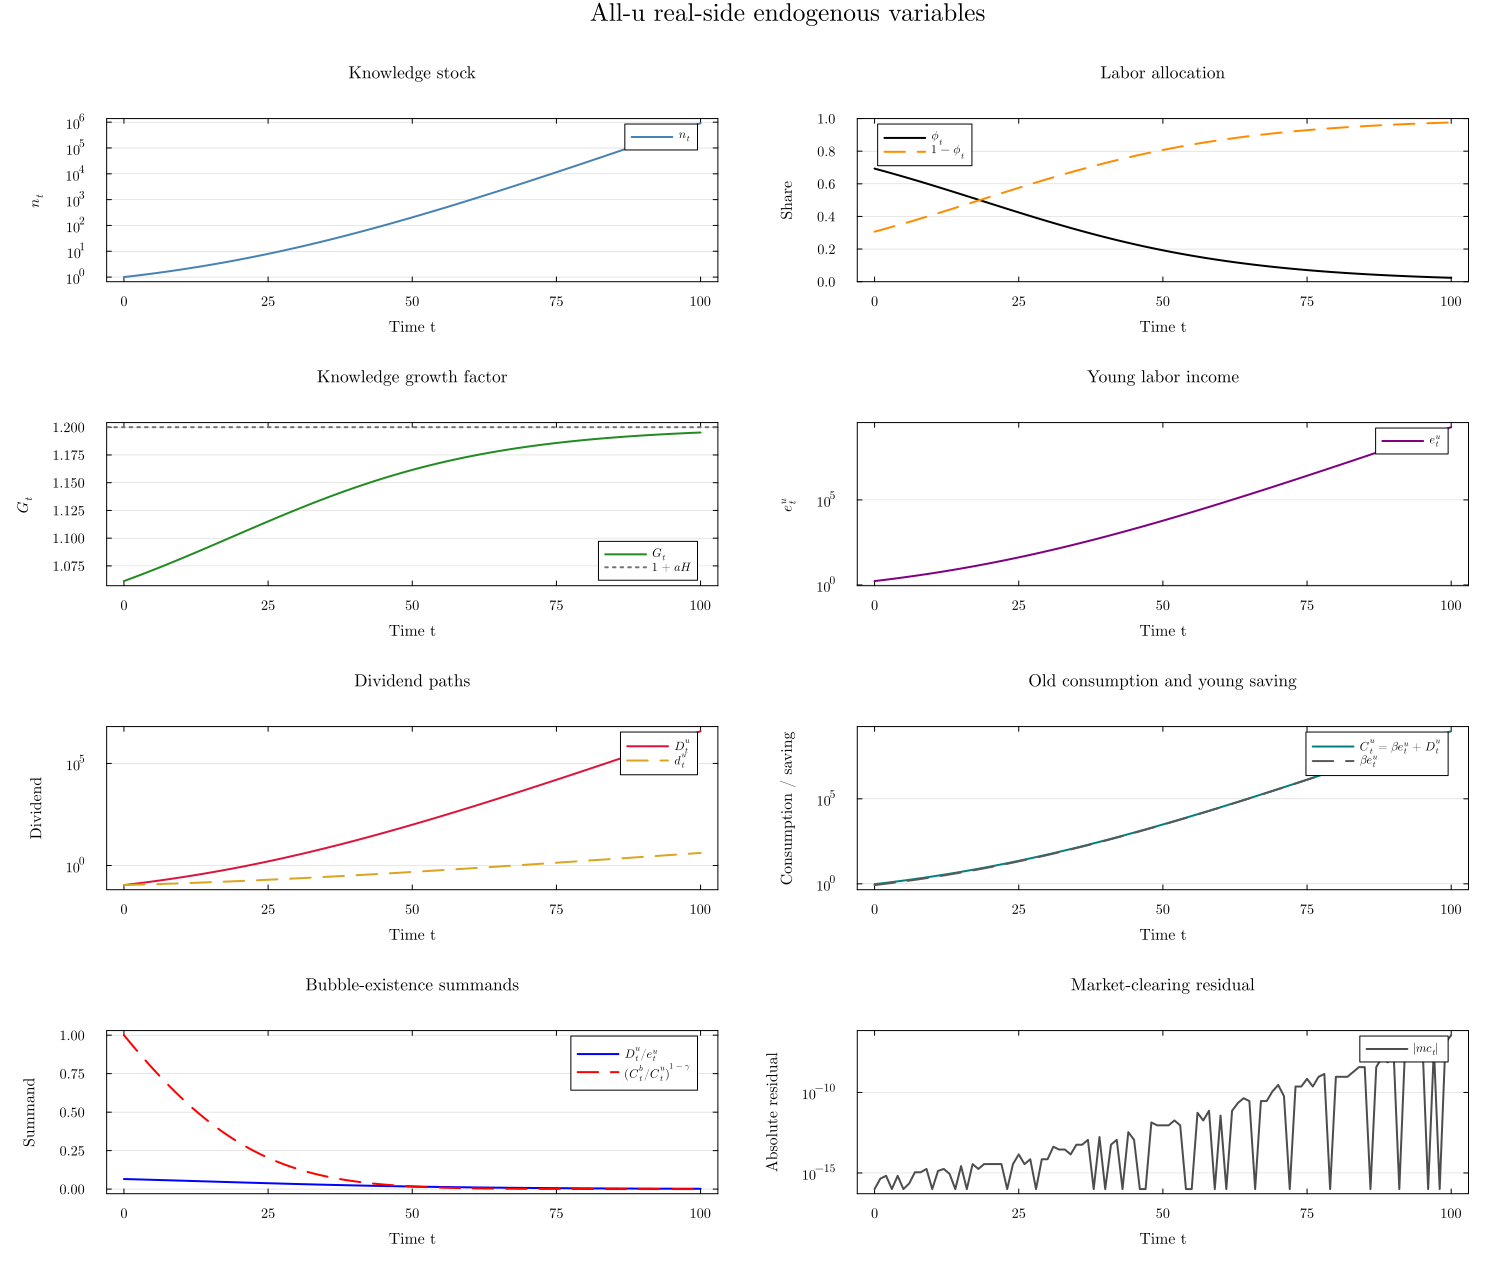

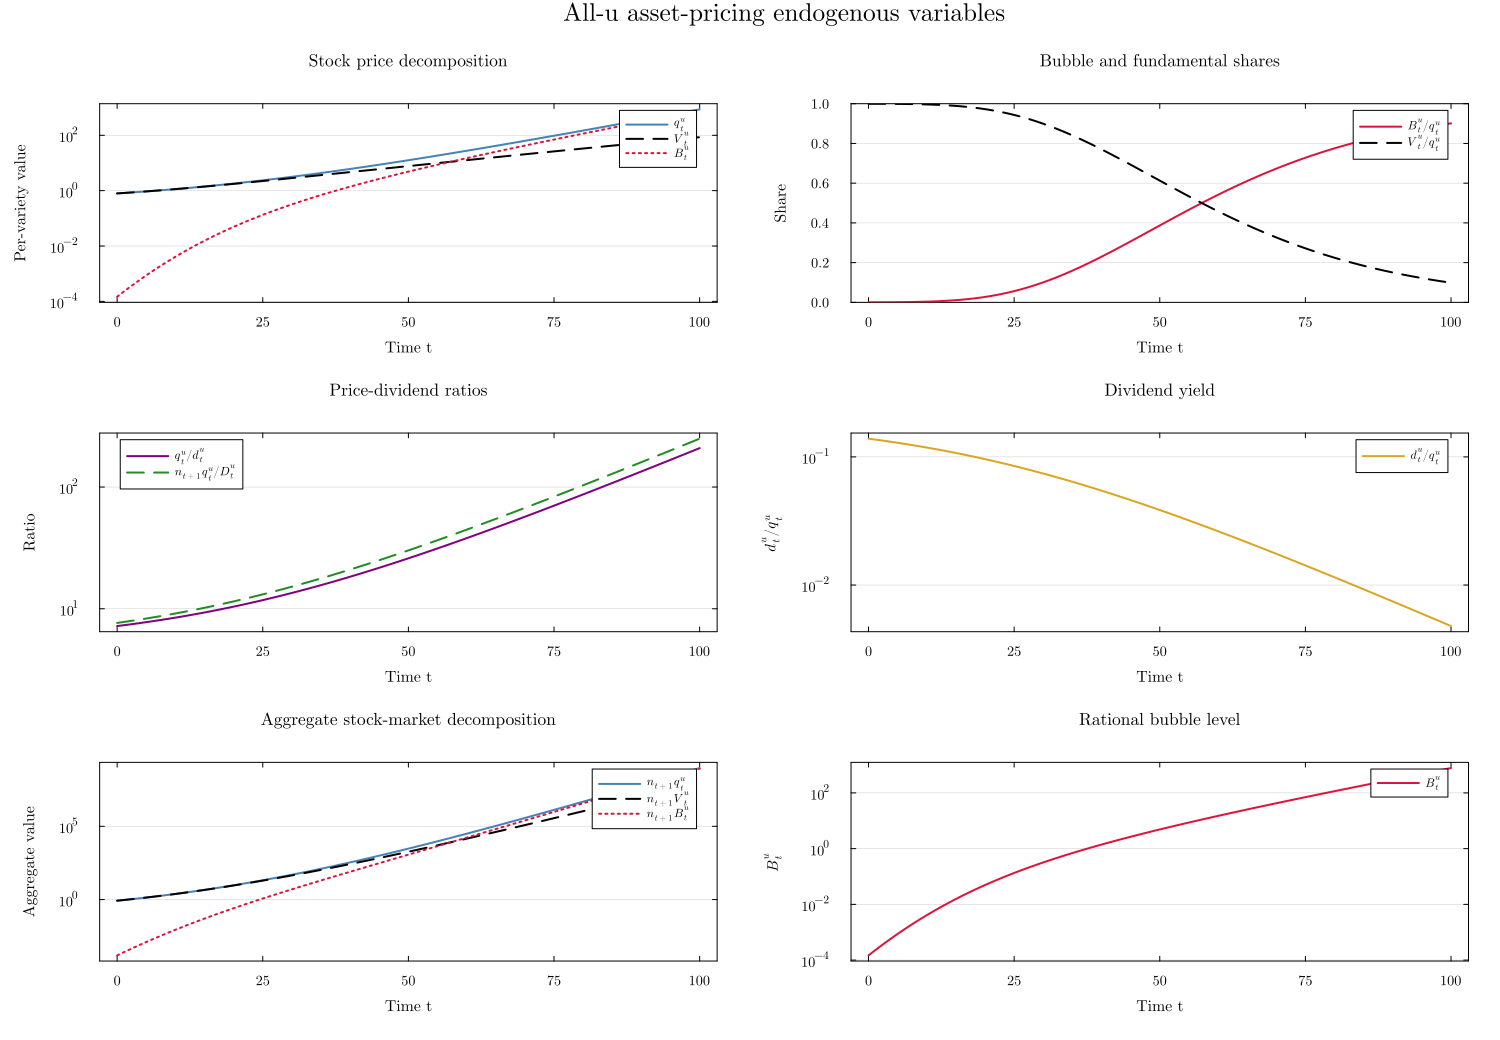

In [5]:
function plot_real_all_u_paths(paths; filename=joinpath(OUTDIR, "hkt_larger_bubble_share_all_u_real_paths.png"))
    p_n = plot(paths.t, paths.n, yscale=:log10,
               xlabel="Time t", ylabel=L"n_t", title="Knowledge stock",
               label=L"n_t", color=:steelblue)

    p_phi = plot(paths.t, paths.phi,
                 xlabel="Time t", ylabel="Share", title="Labor allocation",
                 label=L"\phi_t", color=:black, ylim=(0, 1))
    plot!(p_phi, paths.t, paths.rd_share, label=L"1-\phi_t", color=:darkorange, linestyle=:dash)

    p_G = plot(paths.t, paths.G,
               xlabel="Time t", ylabel=L"G_t", title="Knowledge growth factor",
               label=L"G_t", color=:forestgreen)
    hline!(p_G, [1 + p.aH], label=L"1+aH", color=:gray45, linestyle=:dot)

    p_e = plot(paths.t, paths.e, yscale=:log10,
               xlabel="Time t", ylabel=L"e_t^u", title="Young labor income",
               label=L"e_t^u", color=:purple)

    p_D = plot(paths.t, paths.D_agg, yscale=:log10,
               xlabel="Time t", ylabel="Dividend", title="Dividend paths",
               label=L"D_t^u", color=:crimson)
    plot!(p_D, paths.t, paths.d_per, label=L"d_t^u", color=:goldenrod, linestyle=:dash)

    p_C = plot(paths.t, paths.C_old, yscale=:log10,
               xlabel="Time t", ylabel="Consumption / saving", title="Old consumption and young saving",
               label=L"C_t^u=\beta e_t^u + D_t^u", color=:teal)
    plot!(p_C, paths.t, paths.young_saving, label=L"\beta e_t^u", color=:gray35, linestyle=:dash)

    p_cond = plot(paths.t, paths.cond_2_15a,
                  xlabel="Time t", ylabel="Summand", title="Bubble-existence summands",
                  label=L"D_t^u/e_t^u", color=:blue)
    plot!(p_cond, paths.t, paths.cond_2_15b,
          label=L"(C_t^b/C_t^u)^{1-\gamma}", color=:red, linestyle=:dash)

    p_mc = plot(paths.t, positive_for_log(paths.mc_resid_abs; floor=1e-16), yscale=:log10,
                xlabel="Time t", ylabel="Absolute residual", title="Market-clearing residual",
                label=L"|mc_t|", color=:gray30)

    fig = plot(p_n, p_phi, p_G, p_e, p_D, p_C, p_cond, p_mc,
               layout=(4, 2), size=(1500, 1280), bottom_margin=8mm,
               plot_title="All-u real-side endogenous variables")
    savefig(fig, filename)
    return fig
end

function plot_asset_all_u_paths(paths; filename=joinpath(OUTDIR, "hkt_larger_bubble_share_all_u_asset_paths.png"))
    p_q = plot(paths.t, paths.q, yscale=:log10,
               xlabel="Time t", ylabel="Per-variety value", title="Stock price decomposition",
               label=L"q_t^u", color=:steelblue)
    plot!(p_q, paths.t, positive_for_log(paths.V), label=L"V_t^u", color=:black, linestyle=:dash)
    plot!(p_q, paths.t, positive_for_log(paths.B), label=L"B_t^u", color=:crimson, linestyle=:dot)

    p_share = plot(paths.t, paths.bubble_share,
                   xlabel="Time t", ylabel="Share", title="Bubble and fundamental shares",
                   label=L"B_t^u/q_t^u", color=:crimson, ylim=(0, 1))
    plot!(p_share, paths.t, paths.fundamental_share,
          label=L"V_t^u/q_t^u", color=:black, linestyle=:dash)

    p_pd = plot(paths.t, paths.PD_pv, yscale=:log10,
                xlabel="Time t", ylabel="Ratio", title="Price-dividend ratios",
                label=L"q_t^u/d_t^u", color=:purple)
    plot!(p_pd, paths.t, paths.PD_agg, label=L"n_{t+1}q_t^u/D_t^u", color=:forestgreen, linestyle=:dash)

    p_yield = plot(paths.t, paths.dividend_yield, yscale=:log10,
                   xlabel="Time t", ylabel=L"d_t^u/q_t^u", title="Dividend yield",
                   label=L"d_t^u/q_t^u", color=:goldenrod)

    p_m = plot(paths.t, paths.market_value, yscale=:log10,
               xlabel="Time t", ylabel="Aggregate value", title="Aggregate stock-market decomposition",
               label=L"n_{t+1}q_t^u", color=:steelblue)
    plot!(p_m, paths.t, positive_for_log(paths.market_fundamental),
          label=L"n_{t+1}V_t^u", color=:black, linestyle=:dash)
    plot!(p_m, paths.t, positive_for_log(paths.market_bubble),
          label=L"n_{t+1}B_t^u", color=:crimson, linestyle=:dot)

    p_b = plot(paths.t, positive_for_log(paths.B), yscale=:log10,
               xlabel="Time t", ylabel=L"B_t^u", title="Rational bubble level",
               label=L"B_t^u", color=:crimson)

    fig = plot(p_q, p_share, p_pd, p_yield, p_m, p_b,
               layout=(3, 2), size=(1500, 1040), bottom_margin=8mm,
               plot_title="All-u asset-pricing endogenous variables")
    savefig(fig, filename)
    return fig
end

real_paths_fig = plot_real_all_u_paths(all_u_paths)
asset_paths_fig = plot_asset_all_u_paths(all_u_paths)

display(real_paths_fig)
display(asset_paths_fig)

## Calibration checkpoints

In [6]:
println("Larger bubble-share all-u calibration checkpoints")
println("-"^78)
@printf("%-8s %14s %14s %14s %14s %14s\n", "t", "phi", "G", "q", "B/q", "PD")
for t in (0, 1, 10, 20, 39, 40, 60, 100)
    i = t + 1
    @printf("%-8d %14.6f %14.6f %14.4e %14.4e %14.4e\n",
            t, all_u_paths.phi[i], all_u_paths.G[i], all_u_paths.q[i],
            all_u_paths.bubble_share[i], all_u_paths.PD_pv[i])
end
println()
@printf("max |market-clearing residual| over plotted all-u path: %.4e\n", maximum(all_u_paths.mc_resid_abs))
@printf("saved real-side plot:  %s\n", joinpath(OUTDIR, "hkt_larger_bubble_share_all_u_real_paths.png"))
@printf("saved asset plot:      %s\n", joinpath(OUTDIR, "hkt_larger_bubble_share_all_u_asset_paths.png"))
@printf("saved all-u CSV:       %s\n", csv_path)

Larger bubble-share all-u calibration checkpoints
------------------------------------------------------------------------------
t                   phi              G              q            B/q             PD
0              0.693303       1.061339     7.9450e-01     1.8531e-04     7.2118e+00
1              0.683741       1.063252     8.2013e-01     2.6100e-04     7.3127e+00
10             0.591198       1.081760     1.1395e+00     3.5878e-03     8.4574e+00
20             0.480133       1.103973     1.8068e+00     2.7257e-02     1.0414e+01
39             0.281695       1.143661     5.6721e+00     2.1498e-01     1.7750e+01
40             0.272635       1.145473     6.0764e+00     2.2973e-01     1.8340e+01
60             0.131474       1.173705     2.7560e+01     5.4146e-01     3.8030e+01
100            0.023937       1.195213     8.6504e+02     9.0131e-01     2.0888e+02

max |market-clearing residual| over plotted all-u path: 3.5763e-07
saved real-side plot:  /Users/jipengcheng/Libra